In [18]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("../dataset/processed/credit_card_segmented.csv")
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10127, 28)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,VIP_Flag,Ticket_Size,Utilization,Engagement,Portfolio_Yield_Proxy,CLV_Score,Transaction_Velocity,Customer_Segment
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,1.625,0.061,0,27.238095,0.061224,1.076923,70.040816,1307.428571,3.500000,Dormant
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,3.714,0.105,0,39.121212,0.104651,0.750000,135.104651,1069.578488,2.750000,Dormant
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,2.333,0.000,0,94.350000,0.000000,0.555556,0.000000,1048.333333,1.666667,Dormant
3,Existing Customer,40,F,4,High School,Not_Disclosed,Less than $40K,Blue,34,3,...,2.333,0.760,0,58.550000,0.759734,0.588235,889.648959,1212.146446,1.666667,Revolver
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,2.500,0.000,0,29.142857,0.000000,1.333333,0.000000,1088.000000,2.333333,Dormant


In [20]:
conn = sqlite3.connect("portfolio_analytics.db")
print("SQL database connected")

SQL database connected


In [21]:
df.to_sql("credit_card_portfolio", conn, if_exists="replace", index=False)
print("Dataset loaded into SQL table")

Dataset loaded into SQL table


**Portfolio Size by Segment**

In [22]:
query = """
SELECT
    Customer_Segment,
    COUNT(*) AS customers
FROM credit_card_portfolio
GROUP BY Customer_Segment
ORDER BY customers DESC
"""
segment_counts = pd.read_sql_query(query, conn)

segment_counts

,Customer_Segment,customers
0,Dormant,8250
1,Revolver,1807
2,Transactor,63
3,Power Spender,7


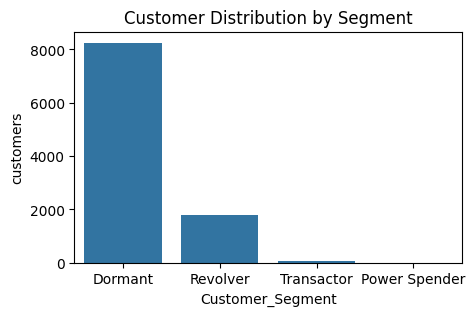

In [23]:
plt.figure(figsize=(5,3))

sns.barplot(data=segment_counts,
            x="Customer_Segment",
            y="customers")

plt.title("Customer Distribution by Segment")
plt.show()

**Average Spend by Income Category**

In [24]:
query = """
SELECT
    Income_Category,
    AVG(Total_Trans_Amt) AS avg_spend,
    COUNT(*) AS customers
FROM credit_card_portfolio
GROUP BY Income_Category
ORDER BY avg_spend DESC
"""
income_spend = pd.read_sql_query(query, conn)

income_spend

,Income_Category,avg_spend,customers
0,$120K +,4529.467675,727
1,$80K - $120K,4482.960261,1535
2,$60K - $80K,4450.712553,1402
3,$40K - $60K,4405.618994,1790
4,Less than $40K,4363.420107,3561
5,Not_Disclosed,4282.211331,1112


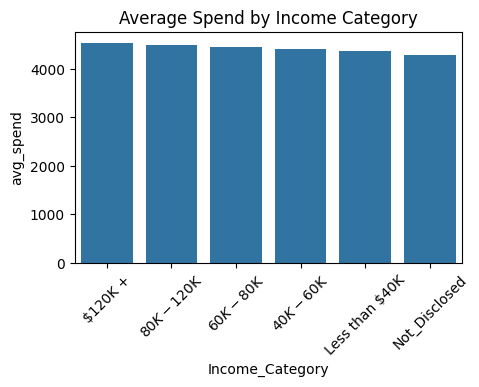

In [25]:
plt.figure(figsize=(5,3))

sns.barplot(data=income_spend,
            x="Income_Category",
            y="avg_spend")

plt.xticks(rotation=45)

plt.title("Average Spend by Income Category")

plt.show()

**Portfolio Yield by Segment**

In [26]:
query = """
SELECT
    Customer_Segment,
    SUM(Portfolio_Yield_Proxy) AS portfolio_value
FROM credit_card_portfolio
GROUP BY Customer_Segment
ORDER BY portfolio_value DESC
"""
yield_segment = pd.read_sql_query(query, conn)

yield_segment

,Customer_Segment,portfolio_value
0,Dormant,6.420571e+06
1,Revolver,4.943481e+06
2,Transactor,7.928837e+04
3,Power Spender,2.934946e+04


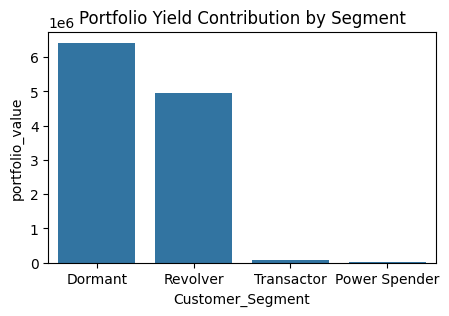

In [27]:
plt.figure(figsize=(5,3))

sns.barplot(data=yield_segment,
            x="Customer_Segment",
            y="portfolio_value")

plt.title("Portfolio Yield Contribution by Segment")

plt.show()

**Churn Risk Indicator**

In [28]:
query = """
SELECT
    Months_Inactive_12_mon,
    COUNT(*) AS customers
FROM credit_card_portfolio
GROUP BY Months_Inactive_12_mon
ORDER BY Months_Inactive_12_mon
"""
inactive = pd.read_sql_query(query, conn)

inactive

,Months_Inactive_12_mon,customers
0,0,29
1,1,2233
2,2,3282
3,3,3846
4,4,435
5,5,178
6,6,124


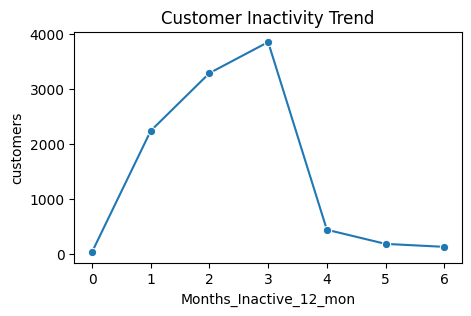

In [29]:
plt.figure(figsize=(5,3))

sns.lineplot(data=inactive,
             x="Months_Inactive_12_mon",
             y="customers",
             marker="o")

plt.title("Customer Inactivity Trend")

plt.show()

**High CLV Customers**

In [30]:
query = """
SELECT
    Customer_Segment,
    AVG(CLV_Score) AS avg_clv
FROM credit_card_portfolio
GROUP BY Customer_Segment
ORDER BY avg_clv DESC
"""
clv_segment = pd.read_sql_query(query, conn)

clv_segment

,Customer_Segment,avg_clv
0,Power Spender,180230.643383
1,Transactor,77590.046102
2,Revolver,13776.112296
3,Dormant,12242.073608


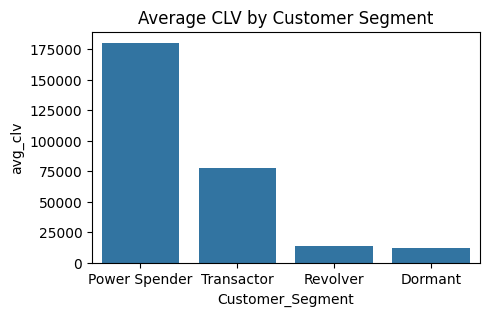

In [31]:
plt.figure(figsize=(5,3))

sns.barplot(data=clv_segment,
            x="Customer_Segment",
            y="avg_clv")

plt.title("Average CLV by Customer Segment")

plt.show()

**Segment Ranking Using Window**

In [32]:
query = """
SELECT
    Customer_Segment,
    SUM(Portfolio_Yield_Proxy) AS segment_revenue,
    
    RANK() OVER (
        ORDER BY SUM(Portfolio_Yield_Proxy) DESC
    ) AS revenue_rank
    
FROM credit_card_portfolio

GROUP BY Customer_Segment;
"""
revenue_rank = pd.read_sql_query(query, conn)

revenue_rank

,Customer_Segment,segment_revenue,revenue_rank
0,Dormant,6.420571e+06,1
1,Revolver,4.943481e+06,2
2,Transactor,7.928837e+04,3
3,Power Spender,2.934946e+04,4


**Revenue Contribution %**

In [33]:
query = """
SELECT
    Customer_Segment,
    SUM(Portfolio_Yield_Proxy) AS revenue,
    
    ROUND(
        SUM(Portfolio_Yield_Proxy) * 100.0 /
        SUM(SUM(Portfolio_Yield_Proxy)) OVER (),
        2
    ) AS revenue_percentage
    
FROM credit_card_portfolio

GROUP BY Customer_Segment

ORDER BY revenue DESC;
"""
revenue_percentage = pd.read_sql_query(query, conn)

revenue_percentage

,Customer_Segment,revenue,revenue_percentage
0,Dormant,6.420571e+06,55.96
1,Revolver,4.943481e+06,43.09
2,Transactor,7.928837e+04,0.69
3,Power Spender,2.934946e+04,0.26


In [36]:
conn.close()
print("SQL database connection closed")

SQL database connection closed
